### Importing required libraries

In [1]:
# !pip install tensorflow
import tensorflow as tf
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

### Downloading and setting up the data
The data will be downloaded from the sklearn servers for the first time when we run `sklearn.datasets.load_digits` and are cached, this dataset will be splitted into test and train split.

In [2]:
X, y = load_digits(return_X_y=True)
X = X / 16.0  # normalize pixel values (originally 0-16) to 0-1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1437, 64) (1437,)
(360, 64) (360,)


### Architecture of the network
We are going to use ANN with same architecture like we did for the last one.

Here by the method of hit and trial, best test set accuracy was obtained at around 60 to 70 epochs.

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=10, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=70)
model.summary()
print("The model was successfully trained.")

Epoch 1/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6500 - loss: 1.6637
Epoch 2/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8845 - loss: 0.7740
Epoch 3/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9235 - loss: 0.3994
Epoch 4/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9506 - loss: 0.2593
Epoch 5/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9555 - loss: 0.1894
Epoch 6/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9596 - loss: 0.1534
Epoch 7/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9694 - loss: 0.1280
Epoch 8/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9749 - loss: 0.1067
Epoch 9/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9784 - loss: 0.0934
Epoch 10/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9798 - loss: 0.0821
Epoch 11/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9861 - loss: 0.0678
Epoch 12/70
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9889 - lo

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,454 (134.59 KB)

 Trainable params: 17,226 (67.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,228 (67.30 KB)

The model was successfully trained.


### Evaluating the model


In [4]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss:.2f}")
print(f"Accuracy: {accuracy*100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9806 - loss: 0.1121  
Loss: 0.11
Accuracy: 98.06%


### Saving the model
We can save the model which gives best accuracy over multiple trainings.

In [5]:
# Model with the best accuracy is saved
# Current max accuracy => 98.33%
# model.save("NN_digit_recognition.keras")

### Loading the model
The saved models can be loaded too, so we don't need to train everytime we predict and the model which is giving best accuracy can be saved.

In [6]:
# saved_model = tf.keras.models.load_model('NN_digit_recognition.keras')
# saved_model.summary()

### Plotting the loss curve

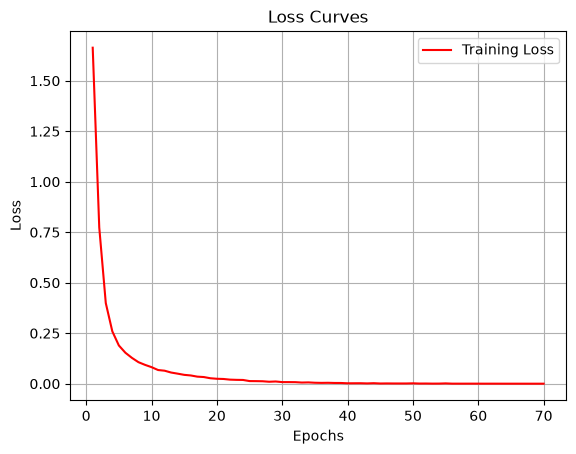

In [7]:
training_loss = history.history['loss']
epochs = range(1, len(training_loss) + 1)

plt.figure()
plt.plot(epochs, training_loss, 'r-', label='Training Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()